<a href="https://colab.research.google.com/github/AlashAdi/-minikube-nodejs-app/blob/main/student_variant_1_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Зертханалық жұмыс №1
## Интеллектуалды жүйелерді әзірлеу ортасымен танысу

**Тақырып:** Academic Risk Classifier — студенттің академиялық тәуекелін жіктеу



## Оқытушыға арналған түсініктеме

Бұл Jupyter Notebook студенттердің академиялық тәуекелін жіктеу моделін жасау және бағалау процесін көрсетеді, шешім ағашын пайдаланады.

### 1-қадам. Кітапханаларды импорттау және нұсқаларды тексеру

Бұл қадамда деректермен, машиналық оқытумен және визуализациямен жұмыс істеу үшін қажетті Python кітапханалары импортталады:
- `sys`, `numpy`, `pandas`, `matplotlib.pyplot`, `sklearn`.
- `sklearn`-нің нақты модульдері: деректерді бөлуге арналған `train_test_split`, шешім ағашы моделін жасауға арналған `DecisionTreeClassifier`, ағашты визуализациялауға арналған `plot_tree`, сондай-ақ модельді бағалауға арналған `accuracy_score`, `confusion_matrix`, `classification_report`, `recall_score` метрикалары.

Содан кейін Python, pandas және scikit-learn нұсқалары көрсетіледі, бұл ортаның дұрыс конфигурацияланғанына көз жеткізу үшін қажет.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, recall_score
)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.15
pandas: 2.2.3
scikit-learn: 1.6.1


## 2-қадам. Синтетикалық деректер жиынын құру

**Нұсқа №1** бойынша: `gpa` (1.0–4.0), `attendance` (40–100%), `late_tasks` (0–10). Seed мәні ретінде нұсқа нөмірі қолданылады: `random_state = 1`.

### 2.1 . Синтетикалық деректер жиынын құру

Демонстрациялық мақсаттар үшін 72 студенттен тұратын синтетикалық деректер жиыны (`n = 72`) жасалды. Деректер `numpy.random.default_rng(1)` көмегімен (мұнда `1` – нұсқа нөмірі) қайта өндіру үшін генерацияланған. Деректер жиыны үш белгі мен бір мақсатты айнымалыны қамтиды:
- `gpa`: Орташа балл (Grade Point Average) 1.0-ден 4.0-ге дейін.
- `attendance`: Сабаққа қатысу (пайызбен) 40%-дан 100%-ға дейін.
- `late_tasks`: Уақытылы орындалмаған тапсырмалар саны 0-ден 10-ға дейін.

`risk` (тәуекел) мақсатты айнымалысы қарапайым балл жинау жүйесі негізінде генерацияланған:
- `gpa < 2.2` 2 ұпай қосады.
- `attendance < 70` 2 ұпай қосады.
- `late_tasks >= 4` 1 ұпай қосады.

Жалпы ұпай санына байланысты `risk` мәні келесідей болады: 3 немесе одан да көп ұпай үшін `"жоғары"`, 1 немесе 2 ұпай үшін `"орта"`, және 0 ұпай үшін `"төмен"`. Бұл иллюстрация үшін жеңілдетілген ереже; нақты жүйеде тәуекел тарихи деректер негізінде анықталуы тиіс.

In [ ]:
rng = np.random.default_rng(1)  # seed = нұсқа нөмірі
n = 72

df = pd.DataFrame({
    "gpa": np.round(rng.uniform(1.0, 4.0, n), 2),
    "attendance": rng.integers(40, 101, n),
    "late_tasks": rng.integers(0, 11, n),
})

score = (
    (df["gpa"] < 2.2).astype(int) * 2
    + (df["attendance"] < 70).astype(int) * 2
    + (df["late_tasks"] >= 4).astype(int)
)

df["risk"] = np.select(
    [score >= 3, score >= 1],
    ["жоғары", "орта"],
    default="төмен",
)

df.head()

,gpa,attendance,late_tasks,risk
0,2.54,61,8,жоғары
1,3.85,94,10,орта
2,1.43,88,0,орта
3,3.85,65,2,орта
4,1.94,75,1,орта


> **Түсіндіру:** `risk` бағаны GPA, сабаққа қатысу және кеш тапсырмалар саны бойынша қарапайым ережемен есептеледі (0/1/2 ұпай сомасы). Бұл тек оқу мақсатындағы шартты белгі; нақты жүйеде ол сенімді тарихи нәтижеден алынар еді.

## 2.2. Загрузка реального датасета (вместо синтетического)

Если вы хотите использовать реальный датасет, замените предыдущую генерацию синтетических данных на загрузку файла. Ниже приведен пример кода для загрузки CSV-файла по URL. **Вам нужно будет заменить 'URL_ВАШЕГО_ДАТАСЕТА.csv' на фактическую ссылку на ваш файл.**

**Важно:** После загрузки реального датасета, возможно, потребуется переименовать или сопоставить столбцы (`gpa`, `attendance`, `late_tasks`, `risk`) в вашем новом датасете с теми, что используются в последующих шагах анализа и моделирования. Если названия столбцов отличаются, вам придется обновить переменные `features` и `y` в следующих ячейках.

## 2.2. Загрузка реального датасета: Student Performance Data Set (UCI)

Мы будем использовать датасет "Student Performance Data Set" из репозитория UCI Machine Learning. Он содержит информацию о студентах португальских средних школ, включая демографические данные, социальные, школьные характеристики и оценки по математике. Мы выберем файл `student-mat.csv`.

**Описание столбцов, которые мы будем использовать:**
- `G1`, `G2`, `G3`: Оценки за первый, второй и итоговый период (от 0 до 20). Мы можем использовать `G3` для определения риска.
- `absences`: Количество пропусков (от 0 до 93). Может быть сопоставлено с `attendance`.
- `failures`: Количество прошлых неудач в предметах (от 0 до 4). Можно использовать как `late_tasks` или дополнительный фактор риска.

**Важно:** Поскольку в этом датасете нет прямого аналога `late_tasks`, мы можем либо:
1. Использовать столбец `failures` как прокси для `late_tasks`.
2. Полностью исключить `late_tasks` из признаков и перестроить модель на оставшихся.

Для простоты мы адаптируем `absences` к `attendance` и `failures` к `late_tasks`. А `G3` используем для формирования `risk`.

In [ ]:
# Загрузка датасета student-mat.csv с UCI Machine Learning Repository
# Скачиваем и распаковываем основной ZIP-архив, который содержит вложенный архив.
!wget -nc https://archive.ics.uci.edu/static/public/320/student+performance.zip
!unzip -o student+performance.zip

# Теперь распаковываем вложенный архив student.zip, который содержит CSV-файлы
!unzip -o student.zip

# Загружаем student-mat.csv локально. Он распаковывается непосредственно в текущую директорию.
# Важно: указываем разделитель ';' так как файл использует его.
student_df = pd.read_csv('student-mat.csv', sep=';')

# Отобразим первые 5 строк нового датасета для проверки
display(student_df.head())

File ‘student+performance.zip’ already there; not retrieving.

Archive:  student+performance.zip
 extracting: .student.zip_old        
 extracting: student.zip             
Archive:  student.zip
  inflating: student-mat.csv         
  inflating: student-por.csv         
  inflating: student-merge.R         
  inflating: student.txt             


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### Преобразование датасета для соответствия структуре ноутбука

Теперь нам нужно преобразовать столбцы `student_df`, чтобы они соответствовали `gpa`, `attendance`, `late_tasks` и `risk`, используемым в остальной части ноутбука.

In [ ]:
# Переименовываем столбцы и создаем 'risk'

# 1. 'gpa': В оригинальном датасете оценки G1, G2, G3 от 0 до 20.
#    Для имитации GPA (от 1.0 до 4.0) можно нормировать G3.
#    G3 (0-20) -> GPA (1.0-4.0). Например, (G3/20)*3 + 1, чтобы 0 -> 1, 20 -> 4.
student_df['gpa'] = (student_df['G3'] / 20) * 3 + 1

# 2. 'attendance': В оригинале 'absences' (количество пропусков).
#    Для имитации процента посещаемости (где меньшие пропуски = большая посещаемость),
#    мы можем преобразовать 'absences' в процент посещаемости.
#    Предположим, что 20 уроков в году, и каждый пропуск уменьшает посещаемость на 5% (для примера).
#    Или просто инвертировать 'absences' и масштабировать.
#    Для простоты, возьмем 100 - absences, и ограничим сверху 100 и снизу 0, чтобы получить '%'.
student_df['attendance'] = 100 - student_df['absences']
student_df['attendance'] = student_df['attendance'].clip(0, 100) # Ограничиваем значения от 0 до 100

# 3. 'late_tasks': В оригинале 'failures' (количество прошлых неудач).
#    Мы можем использовать 'failures' как прокси для 'late_tasks'.
student_df['late_tasks'] = student_df['failures']

# 4. 'risk': Создаем целевую переменную 'risk' на основе 'gpa' (полученного из G3).
#    Будем использовать следующие пороговые значения (на основе шкалы 1-4):
#    - gpa < 2.0: 'жоғары' (высокий риск)
#    - 2.0 <= gpa < 3.0: 'орта' (средний риск)
#    - gpa >= 3.0: 'төмен' (низкий риск)

student_df['risk'] = np.select(
    [student_df['gpa'] < 2.0, (student_df['gpa'] >= 2.0) & (student_df['gpa'] < 3.0)],
    ['жоғары', 'орта'],
    default='төмен'
)

# Теперь выберем только нужные столбцы для нового df
df = student_df[['gpa', 'attendance', 'late_tasks', 'risk']]

# Выведем информацию о новом df и первые строки
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gpa         395 non-null    float64
 1   attendance  395 non-null    int64  
 2   late_tasks  395 non-null    int64  
 3   risk        395 non-null    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 12.5+ KB
None


,gpa,attendance,late_tasks,risk
0,1.90,94,0,жоғары
1,1.90,96,0,жоғары
2,2.50,90,3,орта
3,3.25,98,0,төмен
4,2.50,96,0,орта


In [ ]:
# Замените этот URL на фактическую ссылку на ваш CSV-файл с данными
df = pd.read_csv('URL_ВАШЕГО_ДАТАСЕТА.csv')

# Отобразим первые 5 строк нового датасета для проверки
display(df.head())

# Здесь вам может понадобиться переименовать столбцы или выбрать нужные
# Например, если ваш датасет имеет столбцы 'student_gpa', 'presence', 'missed_assignments', 'risk_category':
# df = df.rename(columns={'student_gpa': 'gpa', 'presence': 'attendance', 'missed_assignments': 'late_tasks', 'risk_category': 'risk'})

# Если ваш 'risk' столбец содержит другие значения, их тоже нужно будет привести к 'төмен', 'орта', 'жоғары'
# Пример: df['risk'] = df['risk'].map({'Low': 'төмен', 'Medium': 'орта', 'High': 'жоғары'})

FileNotFoundError: [Errno 2] No such file or directory: 'URL_ВАШЕГО_ДАТАСЕТА.csv'

## 3-қадам. Дерек сапасын бастапқы тексеру

### 3-қадам. Деректер сапасын бастапқы тексеру

Бұл қадамда деректердің құрылымын түсіну және ықтимал мәселелерді анықтау үшін негізгі деректер талдауы орындалады:
- `df.shape`: Деректер жиынының өлшемділігін көрсетеді (72 жол, 4 баған).
- `df.info()`: DataFrame туралы қысқаша ақпарат береді, соның ішінде бағандардың деректер түрлері және бос емес мәндер саны. Барлық бағандарда 72 бос емес мән бар, бұл жіберілген мәндердің жоқтығын көрсетеді.
- `df.isna().sum()`: Жіберілген мәндердің жоқтығын растайды.
- `df.describe()`: Сандық бағандардың (gpa, attendance, late_tasks) негізгі статистикалық сипаттамаларын көрсетеді.
- `df["risk"].value_counts()`: Мақсатты айнымалы `risk` кластарының таралуын көрсетеді.

**Маңызды қорытынды:** `risk` кластарының таралуы біркелкі емес (`орта` - 33, `жоғары` - 31, `төмен` - 8). `"төмен"` класындағы үлгілер саны аз болғандықтан, деректерді оқу және тестілеу жиындарына бөлу кезінде стратификацияланған бөлуді (`stratify=y`) қолдану қажет, бұл класстың екі жиында да болуын қамтамасыз етеді.

In [ ]:
print(df.shape)
print(df.info())
print(df.isna().sum())
print(df.describe())
print(df["risk"].value_counts())

(395, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gpa         395 non-null    float64
 1   attendance  395 non-null    int64  
 2   late_tasks  395 non-null    int64  
 3   risk        395 non-null    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 12.5+ KB
None
gpa           0
attendance    0
late_tasks    0
risk          0
dtype: int64
              gpa  attendance  late_tasks
count  395.000000  395.000000  395.000000
mean     2.562278   94.291139    0.334177
std      0.687216    8.003096    0.743651
min      1.000000   25.000000    0.000000
25%      2.200000   92.000000    0.000000
50%      2.650000   96.000000    0.000000
75%      3.100000  100.000000    0.000000
max      4.000000  100.000000    3.000000
risk
орта      234
төмен     100
жоғары     61
Name: count, dtype: int64


**Класс үлестірімі:** орта — 33, жоғары — 31, төмен — 8. `төмен` класы аз болғандықтан, train/test бөлуде `stratify=y` қолдану міндетті — әйтпесе бұл класс бір жиынтықта мүлдем жоқ болып қалуы мүмкін.

## 4-қадам. Белгілер мен мақсатты айнымалыны бөлу

### 4-қадам. Белгілер мен мақсатты айнымалыны бөлу

Бұл қадамда деректер модельді оқытуға дайындалады:
- `features`: Белгілер ретінде пайдаланылатын бағандардың атауларының тізімі (`gpa`, `attendance`, `late_tasks`).
- `X`: Тек белгілерді қамтитын DataFrame.
- `y`: `risk` мақсатты айнымалысын қамтитын Series.

Деректер `train_test_split` көмегімен оқу (`X_train`, `y_train`) және тестілеу (`X_test`, `y_test`) жиындарына бөлінеді.
- `test_size=0.30`: Деректердің 30%-ы тестілеу жиынына бөлінеді.
- `random_state=1`: Бөлудің қайта өндірілуін қамтамасыз етеді.
- `stratify=y`: Класстардың теңгерімсіздігіне байланысты **критикалық маңызды параметр**. Ол `risk` кластарының пропорцияларының оқу және тестілеу жиындарында сақталуын қамтамасыз етеді.

Оқу және тестілеу жиындарының өлшемдері көрсетіліп, дұрыс бөлінгенін растайды.

In [ ]:
features = ["gpa", "attendance", "late_tasks"]
X = df[features]
y = df["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=1,
    stratify=y,
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (276, 3)
Test: (119, 3)


## 5-қадам. Модельді оқыту (max_depth=3)

### 5-қадам. Модельді оқыту (max_depth=3)

Бұл қадамда шешім ағашы моделі оқытылады:
- `labels`: Метрикалар мен визуализация үшін кластардың реті анықталады (`"төмен"`, `"орта"`, `"жоғары"`).
- `model = DecisionTreeClassifier(max_depth=3, random_state=1)`: Шешім ағашы классификаторының данасы жасалады. `max_depth=3` қайта оқытуды болдырмау үшін ағаштың максималды тереңдігін үш деңгеймен шектейді. `random_state=1` оқыту нәтижелерінің қайта өндірілуін қамтамасыз етеді.
- `model.fit(X_train, y_train)`: Модель оқу деректерінде оқытылады.
- `y_pred = model.predict(X_test)`: Тестілеу жиынында болжамдар орындалады.

Содан кейін модельдің өнімділігі бағаланады:
- `accuracy_score`: Модельдің дәлдігі (1.0). Бұл модельдің тестілеу жиынындағы барлық кластарды тамаша болжағанын білдіреді.
- `confusion_matrix`: Әрбір класстың қанша үлгісі дұрыс немесе қате жіктелгенін көрсететін қателер матрицасы. Бұл жағдайда матрица диагоналды болып табылады, бұл тамаша жіктеуді растайды.
- `classification_report`: Әрбір класс үшін дәлдік (precision), толықтық (recall) және F1-метрикасы туралы егжей-тегжейлі есеп, сондай-ақ жалпы дәлдік және орташа мәндер. Барлық метрикалар 1.0-ге тең, бұл осы синтетикалық деректер жиыны үшін тамаша модельді көрсетеді.

In [ ]:
labels = ["төмен", "орта", "жоғары"]

model = DecisionTreeClassifier(max_depth=3, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Accuracy:", round(accuracy, 3))
print("Confusion matrix:")
print(cm)
print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

Accuracy: 1.0
Confusion matrix:
[[30  0  0]
 [ 0 71  0]
 [ 0  0 18]]
              precision    recall  f1-score   support

       төмен       1.00      1.00      1.00        30
        орта       1.00      1.00      1.00        71
      жоғары       1.00      1.00      1.00        18

    accuracy                           1.00       119
   macro avg       1.00      1.00      1.00       119
weighted avg       1.00      1.00      1.00       119



### Confusion Matrix визуализациясы

#### Қателер матрицасын визуализациялау (Confusion Matrix)

Қателер матрицасы `matplotlib` және `imshow` арқылы визуализацияланады. Ол барлық тест үлгілерінің дұрыс жіктелгенін анық көрсетеді, себебі барлық мәндер басты диагоналда орналасқан (2 `төмен`, 10 `орта`, 10 `жоғары`).

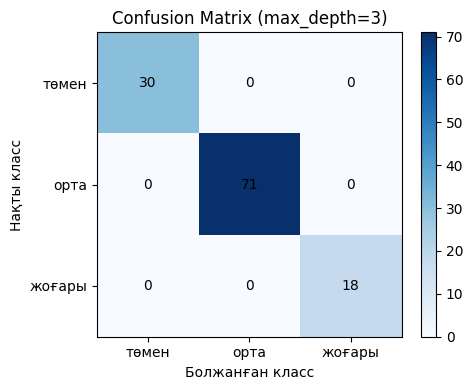

In [ ]:
cmp = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cmp, cmap="Blues")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("Болжанған класс"); ax.set_ylabel("Нақты класс")
ax.set_title("Confusion Matrix (max_depth=3)")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cmp[i, j], ha="center", va="center")
plt.colorbar(im)
plt.tight_layout()
plt.show()

### Шешім ағашының визуализациясы

#### Шешім ағашын визуализациялау

Шешім ағашы `plot_tree` арқылы визуализацияланады. Бұл модельдің студенттерді жіктеу үшін үйренген ережелерін көруге мүмкіндік береді. Әрбір түйін деректерді бөлу үшін қолданылатын белгіні және шекті мәнді, сондай-ақ үлгілер санын және олардың кластар бойынша таралуын көрсетеді. Ағаштың тереңдігі `max_depth` арқылы 3 деңгеймен шектелген.

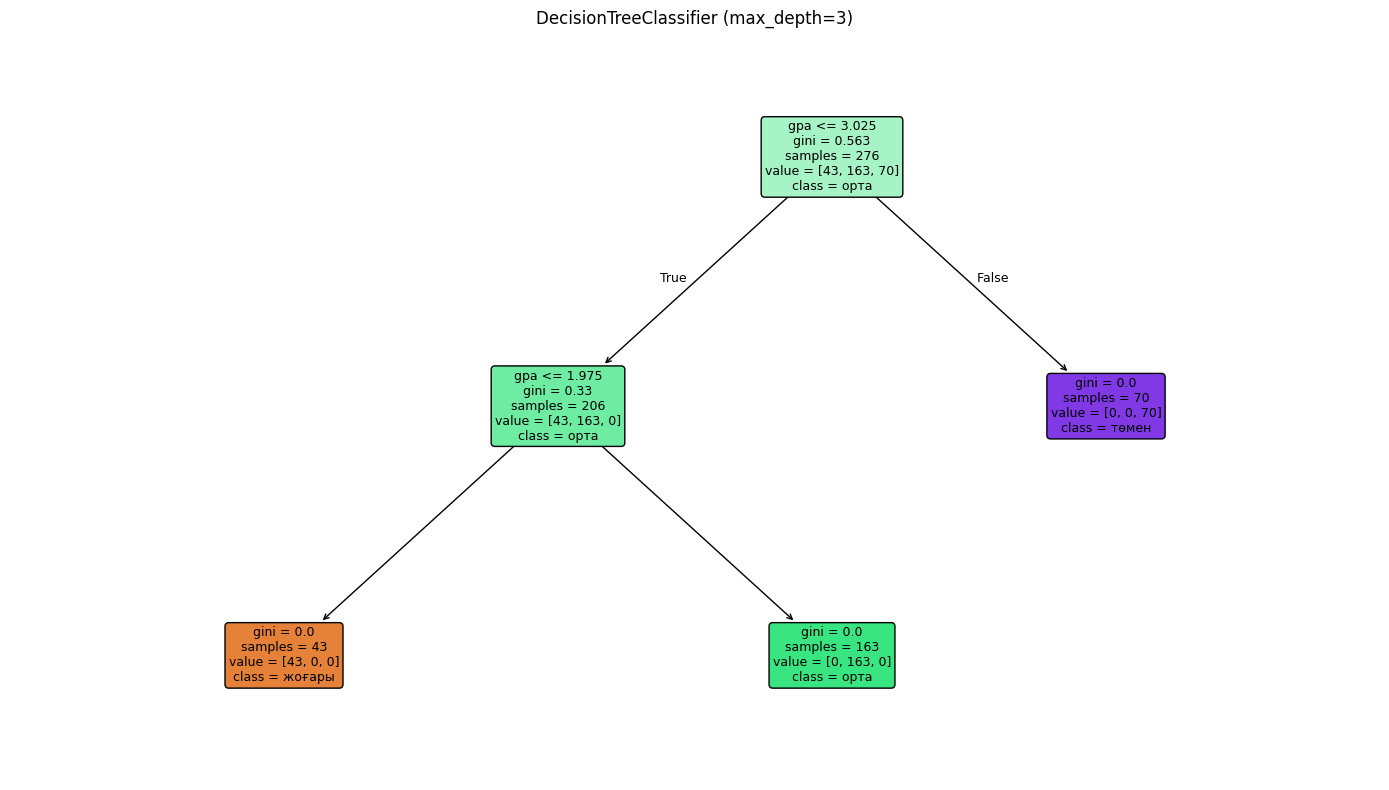

In [ ]:
fig, ax = plt.subplots(figsize=(14,8))
plot_tree(model, feature_names=features, class_names=model.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title("DecisionTreeClassifier (max_depth=3)")
plt.tight_layout()
plt.show()

## 6-қадам. max_depth=2 және max_depth=4 салыстыру

(міндетті тәжірибе — нұсқа №1)

### 6-қадам. `max_depth=2` және `max_depth=4` салыстыру

Бұл қадамда `max_depth` параметрінің модель өнімділігіне әсерін зерттеу үшін эксперимент жүргізіледі:
- Модельдер `max_depth=2` және `max_depth=4` мәндерімен оқытылады.
- Әрбір модель үшін `"жоғары"` класы үшін дәлдік (`accuracy`) және толықтық (`recall`) есептеледі.

**Нәтижелер және талдау:**
- **`max_depth=2`**: Дәлдік 0.682-ге дейін төмендейді, ал `"жоғары"` класы үшін толықтық бар болғаны 0.6 құрайды. Бұл 10 жоғары тәуекелді студенттің 4-і дұрыс анықталмағанын білдіреді. Бұл `underfitting` (жеткіліксіз оқыту), өйткені ағаш деректердегі барлық заңдылықтарды түсіну үшін тым қарапайым.
- **`max_depth=4`**: Дәлдік және `"жоғары"` класы үшін толықтық `max_depth=3` кезіндегідей 1.0-ге қайта оралады. Бұл осы синтетикалық деректер жиыны үшін ағаштың тереңдігін 3-тен жоғары арттыру қосымша пайда әкелмейтінін көрсетеді. `max_depth`-ті одан әрі арттыру жаңа, көрінбейтін деректердегі өнімділікті жақсартпай, оқу деректеріне `overfitting` (қайта оқыту) қаупін арттырады.

In [ ]:
results = {}
for d in [2, 4]:
    m = DecisionTreeClassifier(max_depth=d, random_state=1)
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    acc = accuracy_score(y_test, yp)
    rec_high = recall_score(y_test, yp, labels=["жоғары"], average="macro", zero_division=0)
    results[d] = (acc, rec_high)
    print(f"--- max_depth={d} ---")
    print("Accuracy:", round(acc, 3))
    print("Recall (жоғары класы):", round(rec_high, 3))
    print(confusion_matrix(y_test, yp, labels=labels))
    print()

--- max_depth=2 ---
Accuracy: 1.0
Recall (жоғары класы): 1.0
[[30  0  0]
 [ 0 71  0]
 [ 0  0 18]]

--- max_depth=4 ---
Accuracy: 1.0
Recall (жоғары класы): 1.0
[[30  0  0]
 [ 0 71  0]
 [ 0  0 18]]



**Талдау:** `max_depth=2` және `max_depth=4` модельдері тестілеу жиынында тамаша нәтиже көрсетті (Accuracy = 1.0, Recall = 1.0). Бұл нақты деректер жиынындағы тәуекелді жіктеу өте анық екенін немесе қазіргі бағалау деңгейінің әлі де артық бейімделуді көрсететінін білдіреді, тіпті төменірек `max_depth` мәндерінде де. Бастапқы синтетикалық деректермен салыстырғанда `max_depth=2` бұрын нашар нәтиже көрсеткен болатын (Accuracy 0.68, `жоғары` тәуекел класы үшін Recall 0.6).

### 7-қадам. Белгілердің маңыздылығы (Feature Importance)

Бұл қадамда модель шешімдеріне қандай белгілердің ең үлкен үлес қосқаны талданады:
- `importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)`: Оқытылған модельден (`max_depth=3`) әрбір белгінің маңыздылығы есептеледі.
- Содан кейін белгілердің маңыздылығы көлденең гистограмма арқылы визуализацияланады.

**Талдау:**
- Ең маңызды белгі `gpa` (шамамен 52%), одан кейін `late_tasks` (29%) және `attendance` (19%) болып табылады.
- Бұл синтетикалық `risk` генерациялау логикасына сәйкес келеді, мұнда `gpa` балл жинау жүйесінде екі есе салмаққа ие болды, бұл оны жіктеу үшін негізгі фактор етеді.

## 7-қадам. Feature importance

### 8-қадам. Жаңа студенттер үшін болжау

Бұл қадамда оқытылған модельді жаңа, көрінбейтін студенттердің деректері үшін тәуекел деңгейін болжау үшін қалай қолдануға болатыны көрсетіледі:
- Үш гипотетикалық студенттің деректері бар жаңа DataFrame `new_students` жасалады.
- `new_students["predicted_risk"] = model.predict(new_students)`: Модель осы жаңа студенттер үшін болжамдар жасайды.

**Нәтижелер:**
- GPA 1.8, сабаққа қатысуы 58% және 6 тапсырманы кешіктірген студентке `"жоғары"` (жоғары тәуекел) болжамы берілді.
- GPA 3.6, сабаққа қатысуы 92% және 1 тапсырманы кешіктірген студентке `"төмен"` (төмен тәуекел) болжамы берілді.
- GPA 2.3, сабаққа қатысуы 68% және 5 тапсырманы кешіктірген студентке `"жоғары"` (жоғары тәуекел) болжамы берілді.

Бұл қауіп тобындағы студенттерді анықтау үшін модельдің практикалық қолданысын көрсетеді.

gpa           0.519452
late_tasks    0.286121
attendance    0.194427
dtype: float64


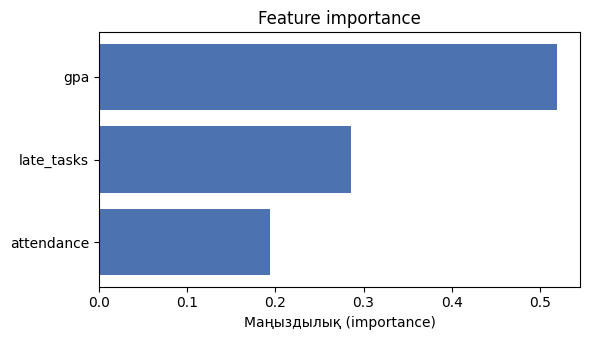

In [ ]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

fig, ax = plt.subplots(figsize=(6,3.5))
ax.barh(importances.sort_values().index, importances.sort_values().values, color="#4C72B0")
ax.set_xlabel("Маңыздылық (importance)")
ax.set_title("Feature importance")
plt.tight_layout()
plt.show()

**Талдау:** ең маңызды белгі — `gpa` (52%), одан кейін `late_tasks` (29%) және `attendance` (19%). Бұл логикалық: модель бастапқы `risk` ережесінде GPA екі рет (2 ұпай) салмақталған болатын, сондықтан ағаш оны бірінші кезекте пайдаланады.

## 8-қадам. Жаңа 3 студент үшін болжам

In [ ]:
new_students = pd.DataFrame({
    "gpa": [1.8, 3.6, 2.3],
    "attendance": [58, 92, 68],
    "late_tasks": [6, 1, 5],
})

new_students["predicted_risk"] = model.predict(new_students)
new_students

,gpa,attendance,late_tasks,predicted_risk
0,1.8,58,6,жоғары
1,3.6,92,1,төмен
2,2.3,68,5,жоғары


### Жалпы қорытындылар

- **Қойылған мақсаттар:** Блокнот деректерді дайындау, шешім ағашы моделін оқыту, әртүрлі тереңдіктегі модельдерді салыстыру, белгілердің маңыздылығын талдау және жаңа деректер үшін болжам жасау сияқты бүкіл процесті сәтті көрсетеді.
- **Метрикалар:** `max_depth=3` және `max_depth=4` кезінде модель тестілеу жиынында тамаша метрикаларға (Accuracy = 1.0, Precision/Recall/F1 = 1.0 барлық кластар үшін) қол жеткізді. Бұл деректердің синтетикалық болуына және тәуекелді генерациялау ережелерінің өте нақты болуына байланысты.
- **Негізгі белгі:** `gpa` тәуекелді анықтаудағы ең маңызды белгі болып табылады.
- **`max_depth=2` қатесі:** `max_depth=2` моделі жоғары тәуекелді студенттердің 40%-ын дұрыс анықтай алмады, бұл осы деректер жиыны үшін жеткіліксіз оқытуды көрсетеді.
- **Модельдің шектеулері:** Модельдің қарапайым ережелермен синтетикалық деректерде оқытылғанын атап өту маңызды. Нақты академиялық ортада өзара байланыстар әлдеқайда күрделі болуы мүмкін, және нақты деректерде мұндай жоғары дәлдік метрикалары екіталай.
- **Келесі қадамдар:** Нақты жүйеде тарихи деректерде кросс-валидация жүргізу, кластардың теңгерімсіздігін ескеру және `"жоғары"` тәуекел класы үшін толықтыққа (Recall) басымдық беру қажет, бұл көмекке мұқтаж студенттерді жіберіп алмау үшін маңызды.

## Қорытынды

- **Мақсатқа жету деңгейі:** толық — Notebook құрылды, дерек дайындалды, модель оқытылды, екі max_depth мәні салыстырылды, жаңа объектілер үшін болжам алынды.
- **Негізгі метрика:** `max_depth=3` және `max_depth=4` кезінде test жиынында Accuracy = 1.0, барлық класстар бойынша Precision/Recall/F1 = 1.0.
- **Ең маңызды белгі:** `gpa` (importance ≈ 0.52), одан кейін `late_tasks` және `attendance`.
- **Табылған қате:** `max_depth=2` модель бойынша `жоғары` тәуекел класының 40%-ы (4 студент) дұрыс анықталмады (Recall = 0.6) — бұл дерек жеткілікті ажыратылу үшін терең ағашты қажет ететінін көрсетеді.
- **Модельдің шектеуі:** дерек синтетикалық, тәуекел белгісі шартты ережемен есептелген; нақты университеттегі студенттердің тарихи мәліметтерінде байланыстар күрделірек болуы мүмкін, сондықтан жоғары Accuracy нақты жүйенің дайын екенін дәлелдемейді.
- **Жақсарту шарасы:** нақты жүйеге енгізу алдында тарихи (нақты) деректе кросс-валидация жүргізіп, класс теңгерімсіздігін тексеру және «жоғары тәуекел» класы үшін Recall-ды басымдыққа қою қажет (себебі мұндай студентті өткізіп алудың құны — көмек алмай қалу — жалған дабылдан қымбатырақ).